In [4]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
adata_root = sc.read_csv('/root/downloads/single_cell_data/GSE123818_Root_single_cell_wt_datamatrix.csv.gz').T
print(adata_root)

AnnData object with n_obs × n_vars = 4727 × 27629


线粒体基因数量： 120
叶绿体基因数量： 88


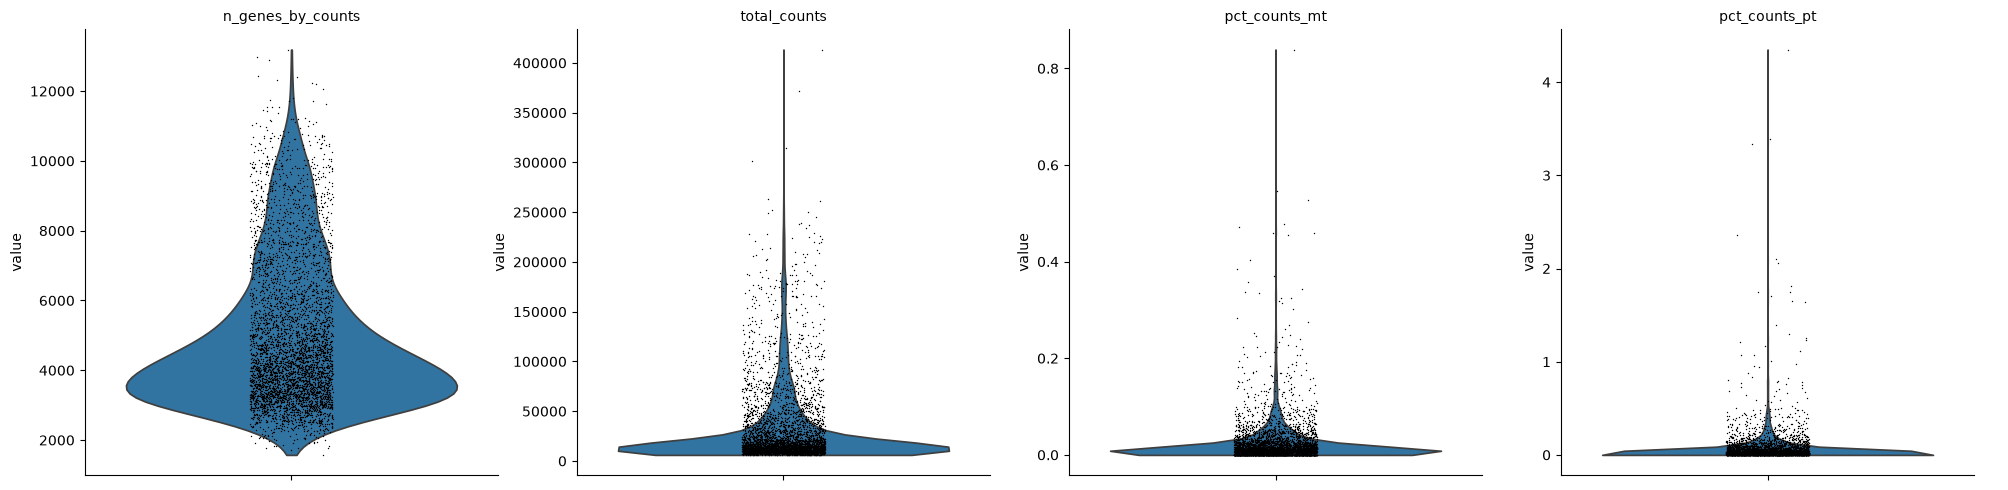

In [7]:
adata_root.var_names_make_unique()
adata_root.var['mt'] = adata_root.var_names.str.startswith('ATMG')
adata_root.var['pt'] = adata_root.var_names.str.startswith('ATCG')

print('线粒体基因数量：', adata_root.var['mt'].sum())
print('叶绿体基因数量：', adata_root.var['pt'].sum())

sc.pp.calculate_qc_metrics(
    adata_root,
    qc_vars=['mt','pt'],
    percent_top=None,
    log1p=False,
    inplace=True
)

sc.pl.violin(
    adata_root,
    ['n_genes_by_counts', 'total_counts', 'pct_counts_mt', 'pct_counts_pt'],
    multi_panel=True
)

In [8]:
sc.pp.filter_cells(adata_root, min_genes=1000)
sc.pp.filter_genes(adata_root, min_counts=3)
adata_root = adata_root[adata_root.obs['pct_counts_mt'] < 5, :]
adata_root = adata_root[adata_root.obs['pct_counts_pt'] < 5, :]
print('过滤后的细胞数和基因数：', adata_root)

过滤后的细胞数和基因数： View of AnnData object with n_obs × n_vars = 4727 × 22110
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_pt', 'pct_counts_pt', 'n_genes'
    var: 'mt', 'pt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_counts'


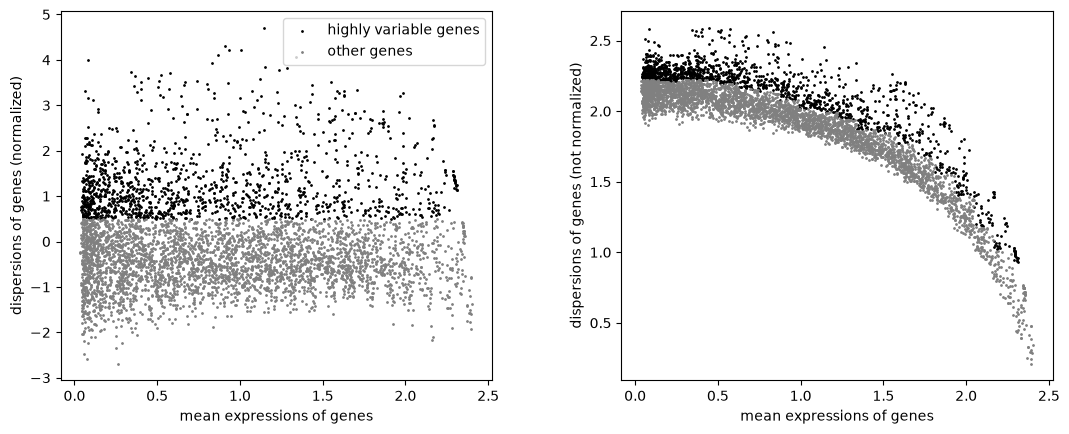

/root/miniconda3/envs/single_cell/lib/python3.12/site-packages/scanpy/preprocessing/_simple.py:672: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


🎉 标准化、去噪与高变基因筛选已全部搞定！当前数据形态： AnnData object with n_obs × n_vars = 4727 × 1299
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_pt', 'pct_counts_pt', 'n_genes'
    var: 'mt', 'pt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'hvg'


In [15]:
sc.pp.normalize_total(adata_root, target_sum=1e4)
sc.pp.log1p(adata_root)
sc.pp.highly_variable_genes(adata_root, min_mean=0.0125, max_mean=3, min_disp=0.5)
sc.pl.highly_variable_genes(adata_root)
adata_root.raw = adata_root
adata_root = adata_root[:, adata_root.var['highly_variable']]
sc.pp.regress_out(adata_root, ['total_counts', 'pct_counts_mt', 'pct_counts_pt'])
sc.pp.scale(adata_root, max_value=10)
print("🎉 标准化、去噪与高变基因筛选已全部搞定！当前数据形态：", adata_root)

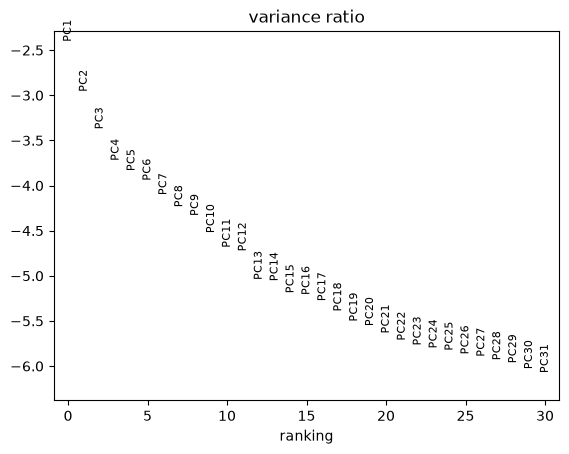

In [18]:
sc.tl.pca(adata_root, svd_solver='arpack')
sc.pl.pca_variance_ratio(adata_root, log=True, n_pcs=30)

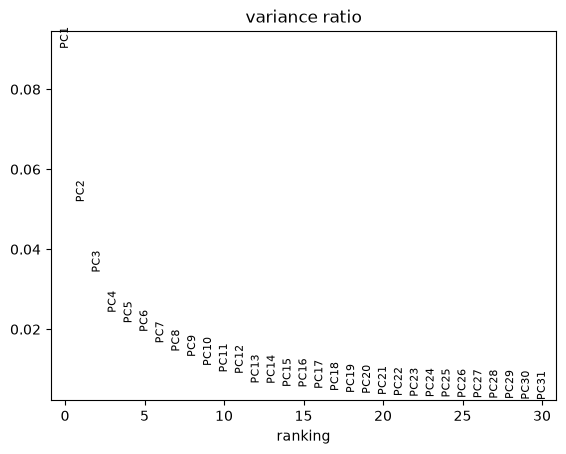

In [20]:
sc.pl.pca_variance_ratio(adata_root, log=False, n_pcs=30)

/tmp/ipykernel_145706/1632831930.py:3: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_root, resolution=0.6)


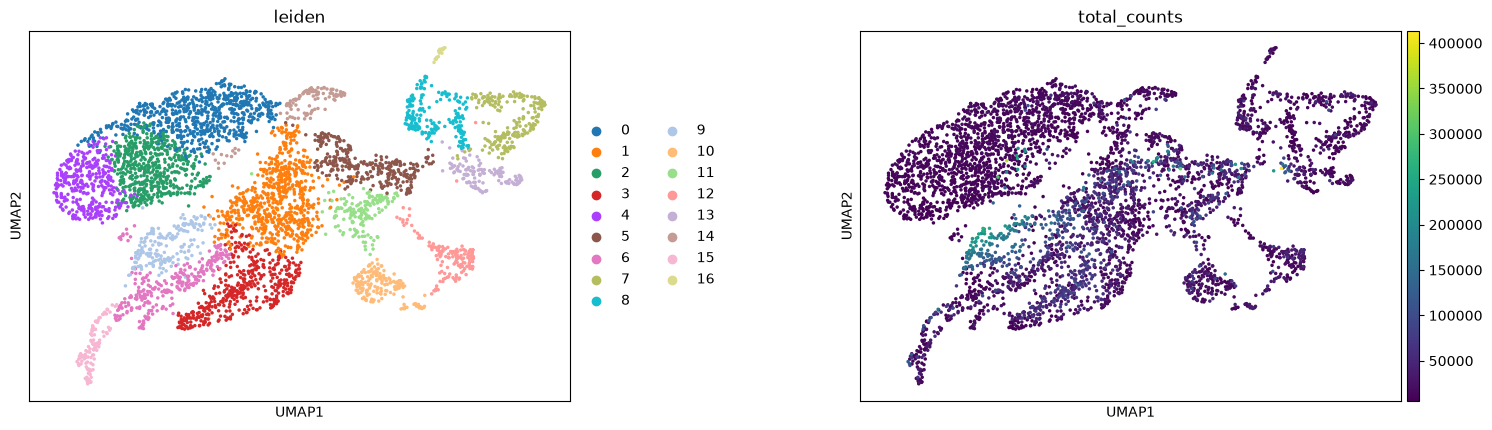

In [21]:
sc.pp.neighbors(adata_root, n_pcs=20, n_neighbors=10)
sc.tl.umap(adata_root)
sc.tl.leiden(adata_root, resolution=0.6)
sc.pl.umap(
    adata_root,
    color=['leiden', 'total_counts'],
    wspace=0.4,
    save='arabidopsis_root.png'
)

=== 正在为你核对基因‘户口’ ===
【Columella (根冠柱)】: 成功匹配 1/3 个基因
【QC (静止中心)】: 成功匹配 1/2 个基因
【Stem Cell Niche (干细胞区)】: 成功匹配 2/2 个基因
【Endodermis (内皮层)】: 成功匹配 3/3 个基因
【Cortex (皮层)】: 成功匹配 1/2 个基因
⚠️ 警告：【Atrichoblast (无根毛表皮)】的所有 Marker 在数据集中均未找到，已被跳过！
⚠️ 警告：【Trichoblast (根毛表皮)】的所有 Marker 在数据集中均未找到，已被跳过！
【Phloem (韧皮部)】: 成功匹配 1/2 个基因
【Xylem (木质部导管)】: 成功匹配 2/2 个基因


/root/miniconda3/envs/single_cell/lib/python3.12/site-packages/scanpy/plotting/_utils.py:338: UserWarning: Glyph 26681 (\N{CJK UNIFIED IDEOGRAPH-6839}) missing from font(s) DejaVu Sans.
  plt.savefig(filename, dpi=dpi, bbox_inches="tight")
/root/miniconda3/envs/single_cell/lib/python3.12/site-packages/scanpy/plotting/_utils.py:338: UserWarning: Glyph 20896 (\N{CJK UNIFIED IDEOGRAPH-51A0}) missing from font(s) DejaVu Sans.
  plt.savefig(filename, dpi=dpi, bbox_inches="tight")
/root/miniconda3/envs/single_cell/lib/python3.12/site-packages/scanpy/plotting/_utils.py:338: UserWarning: Glyph 26609 (\N{CJK UNIFIED IDEOGRAPH-67F1}) missing from font(s) DejaVu Sans.
  plt.savefig(filename, dpi=dpi, bbox_inches="tight")
/root/miniconda3/envs/single_cell/lib/python3.12/site-packages/scanpy/plotting/_utils.py:338: UserWarning: Glyph 38745 (\N{CJK UNIFIED IDEOGRAPH-9759}) missing from font(s) DejaVu Sans.
  plt.savefig(filename, dpi=dpi, bbox_inches="tight")
/root/miniconda3/envs/single_cell/lib/py

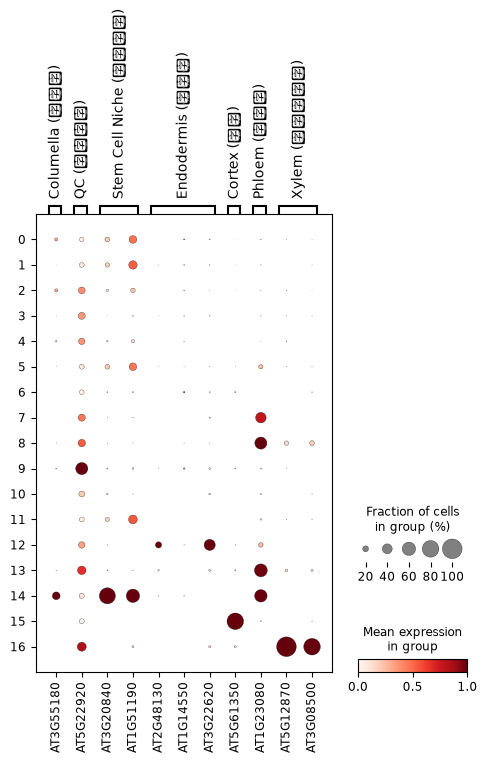

In [25]:
# 运行差异基因分析 
sc.tl.rank_genes_groups(adata_root, groupby='leiden', method='wilcoxon')

# 拟南芥根部Marker 列表
marker_genes_tair = {
    'Columella (根冠柱)': ['AT1G26680', 'AT3G55180', 'AT1G24400'],  # COBL2, BRN1, SMB
    'QC (静止中心)': ['AT5G22920', 'AT2G27060'],                     # WOX5, SCR
    'Stem Cell Niche (干细胞区)': ['AT3G20840', 'AT1G51190'],         # PLT1, PLT2
    'Endodermis (内皮层)': ['AT2G48130', 'AT1G14550', 'AT3G22620'],   # SCR, PER3
    'Cortex (皮层)': ['AT5G25030', 'AT5G61350'],                      # PEP (AED3)
    'Atrichoblast (无根毛表皮)': ['AT1G79840', 'AT4G00730'],          # GL2, ANL2
    'Trichoblast (根毛表皮)': ['AT5G18120', 'AT5G41240'],             # EXPA7, COBL9
    'Phloem (韧皮部)': ['AT1G23080', 'AT1G74790'],                    # PIN7, APL
    'Xylem (木质部导管)': ['AT5G12870', 'AT3G08500']                  # MYB46, MYB83
}

all_existing_genes = set(adata_root.raw.var_names)
safe_marker_genes = {}

print("=== 正在为你核对基因‘户口’ ===")
for cell_type, genes in marker_genes_tair.items():
    # 只保留存在于 adata_root.raw.var_names 中的基因
    valid_genes = [g for g in genes if g in all_existing_genes]
    if valid_genes:
        safe_marker_genes[cell_type] = valid_genes
        print(f"【{cell_type}】: 成功匹配 {len(valid_genes)}/{len(genes)} 个基因")
    else:
        print(f"⚠️ 警告：【{cell_type}】的所有 Marker 在数据集中均未找到，已被跳过！")

# 绘制气泡图
sc.pl.dotplot(
    adata_root,
    safe_marker_genes,
    groupby='leiden',
    use_raw=True,
    standard_scale='var',
    save='root_markers_dotplot.png'
)

In [26]:
# 打印当前所有的 Leiden 分群编号
print("当前的聚类群：", adata_root.obs['leiden'].cat.categories)

当前的聚类群： Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12',
       '13', '14', '15', '16'],
      dtype='str')
